In [33]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy.optimize import curve_fit

In [2]:
filename = '/Users/coletamburri/Desktop/latescan.npz'

In [3]:
latescan = np.load(filename)

In [4]:
latescan

NpzFile '/Users/coletamburri/Desktop/latescan.npz' with keys: flarelate, scaledlate, timesslate, wllate

In [8]:
timeslate=latescan['timesslate']
wl = latescan['wllate']
intensity = latescan['flarelate']

poschoice = 831-(148+7*91)
ylo=1268
yhi=1392

wllo = 600
wlhi = 650

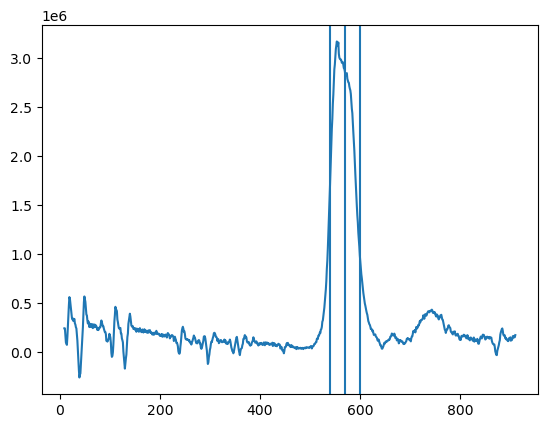

In [17]:
fig,ax=plt.subplots();
ax.plot(intensity[45,:,1360])
ax.axvline(600)
ax.axvline(570)
ax.axvline(540)

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_12469/2884139484.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()


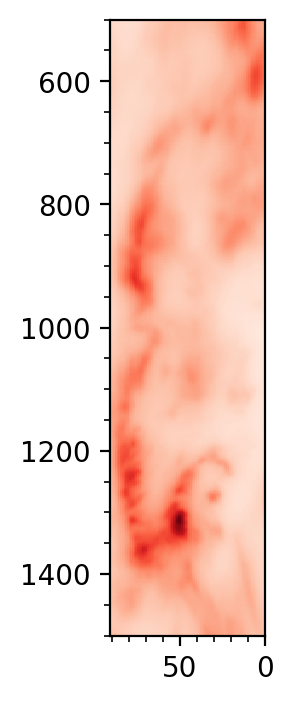

In [18]:
fig,ax=plt.subplots(dpi=200,figsize=(1,4));
ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()
ax.invert_xaxis()
ax.set_ylim([500,1500])
ax.invert_yaxis()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_12469/341406691.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()


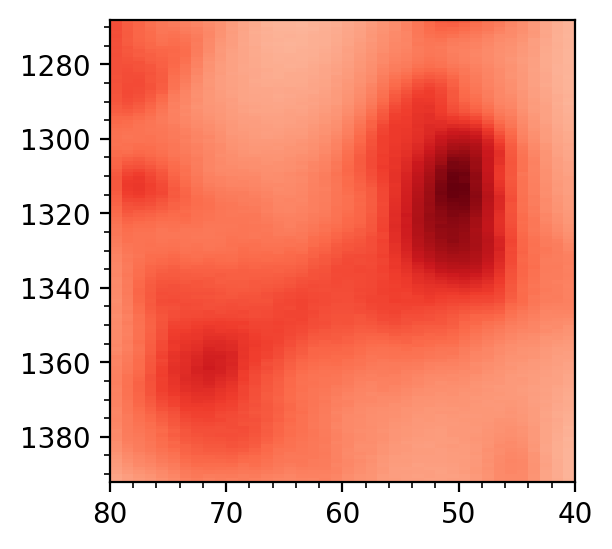

In [19]:
fig,ax=plt.subplots(dpi=200,figsize=(3,3));
ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()
ax.invert_xaxis()
ax.set_ylim([ylo,yhi])
ax.set_xlim([80,40])
ax.invert_yaxis()
#ax.set_yticks([1300,1320,1340])
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())


/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_12469/3984509181.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()


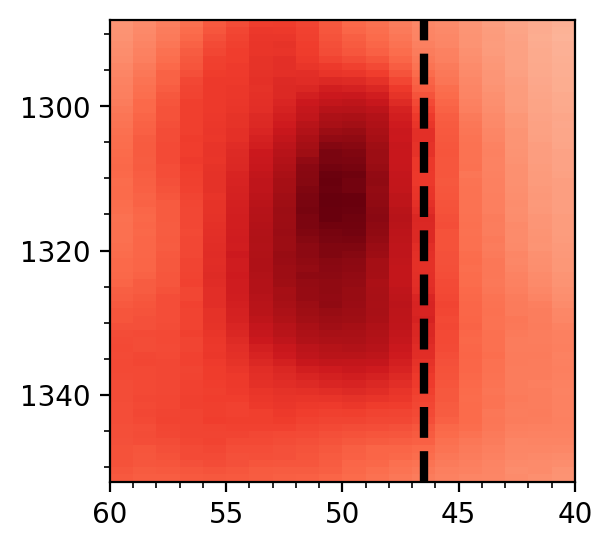

In [20]:
fig,ax=plt.subplots(dpi=200,figsize=(3,3));
ax.pcolormesh(np.transpose(intensity[:,600,:]),cmap='Reds');fig.show()
ax.invert_xaxis()
ax.set_ylim([ylo+20,yhi-40])
ax.set_xlim([60,40])
ax.invert_yaxis()
ax.set_yticks([1300,1320,1340])
ax.axvline(poschoice+0.5,c='black',linestyle='dashed',linewidth=3)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())




In [21]:
choicepos = intensity[poschoice,wllo:wlhi,ylo+20:yhi-40]
vmin = np.percentile(choicepos, 30)
vmax = np.percentile(choicepos, 99)

Y=np.arange(ylo+20,yhi-40)

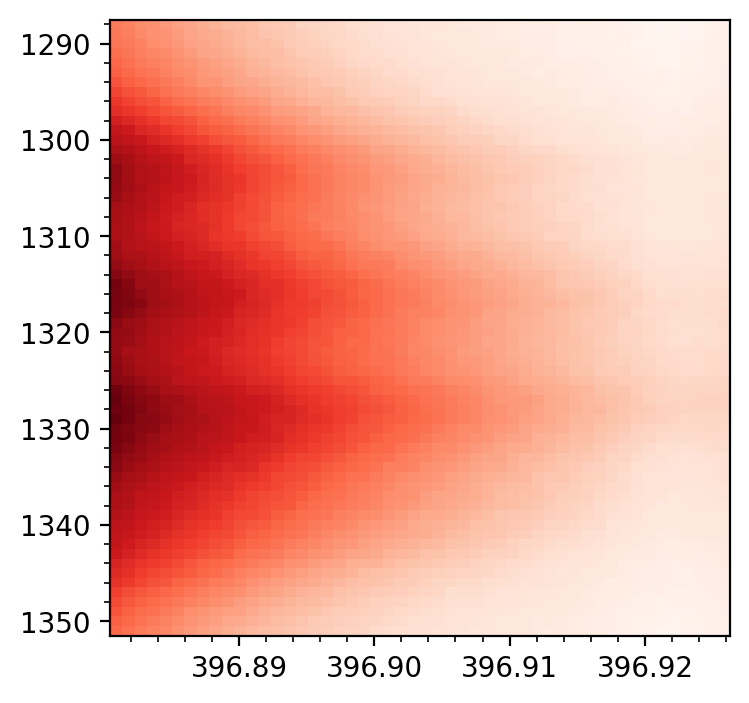

In [22]:
colors = plt.cm.jet(np.linspace(0,1,10))

inds=[10,21,35,48] #minima between peaks

fig,ax=plt.subplots(dpi=200,figsize=(4,4));
ax.pcolormesh(wl[wllo:wlhi],Y,np.transpose(choicepos),cmap='Reds')
l=0
# for i in np.linspace(396.881,396.92,9):
#     l+=1
#     ax.axvline(i,c=colors[l],linestyle='dashed',linewidth=2)
# ax.axhline(ylo+20+inds[0],linestyle='dashdot',color='#8250C4')
# ax.axhline(ylo+20+inds[1],linestyle='dashed',color='#8250C4')
# ax.axhline(ylo+20+inds[2],linestyle='solid',color='#8250C4')
# ax.axhline(ylo+20+inds[3],linestyle='dotted',color='#8250C4')

# ax.axhline(ylo+20+np.round((inds[1]+inds[0])/2),linestyle='dashdot',color='black')
# ax.axhline(ylo+20+np.round((inds[2]+inds[1])/2),linestyle='dashed',color='black')
# ax.axhline(ylo+20+np.round((inds[3]+inds[2])/2),linestyle='solid',color='black')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.invert_yaxis()

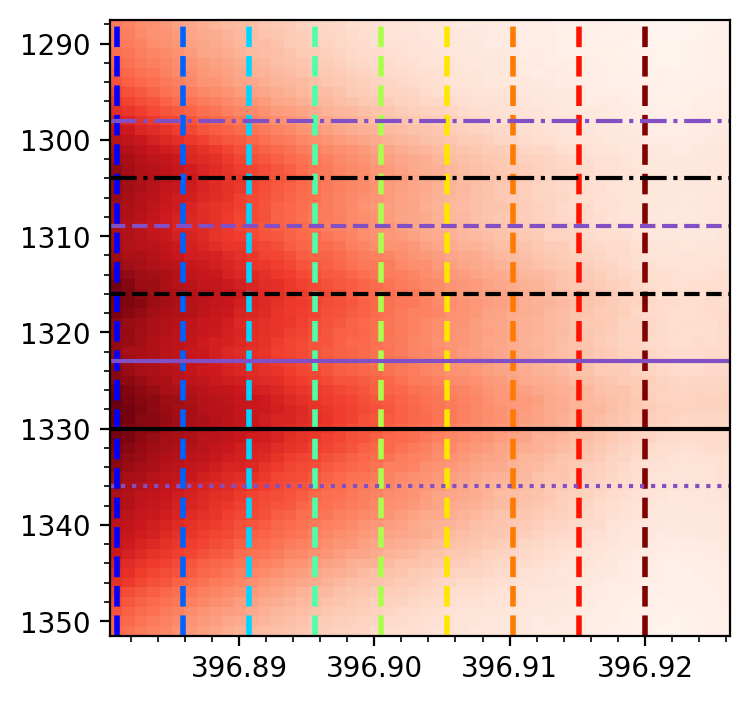

In [23]:
colors = plt.cm.jet(np.linspace(0,1,10))

inds=[10,21,35,48] #minima between peaks

fig,ax=plt.subplots(dpi=200,figsize=(4,4));
ax.pcolormesh(wl[wllo:wlhi],Y,np.transpose(choicepos),cmap='Reds')
l=0
for i in np.linspace(396.881,396.92,9):
    l+=1
    ax.axvline(i,c=colors[l],linestyle='dashed',linewidth=2)
ax.axhline(ylo+20+inds[0],linestyle='dashdot',color='#8250C4')
ax.axhline(ylo+20+inds[1],linestyle='dashed',color='#8250C4')
ax.axhline(ylo+20+inds[2],linestyle='solid',color='#8250C4')
ax.axhline(ylo+20+inds[3],linestyle='dotted',color='#8250C4')

ax.axhline(ylo+20+np.round((inds[1]+inds[0])/2),linestyle='dashdot',color='black')
ax.axhline(ylo+20+np.round((inds[2]+inds[1])/2),linestyle='dashed',color='black')
ax.axhline(ylo+20+np.round((inds[3]+inds[2])/2),linestyle='solid',color='black')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.invert_yaxis()

In [24]:
ylo+20+np.round((inds[1]+inds[0])/2)

np.float64(1304.0)

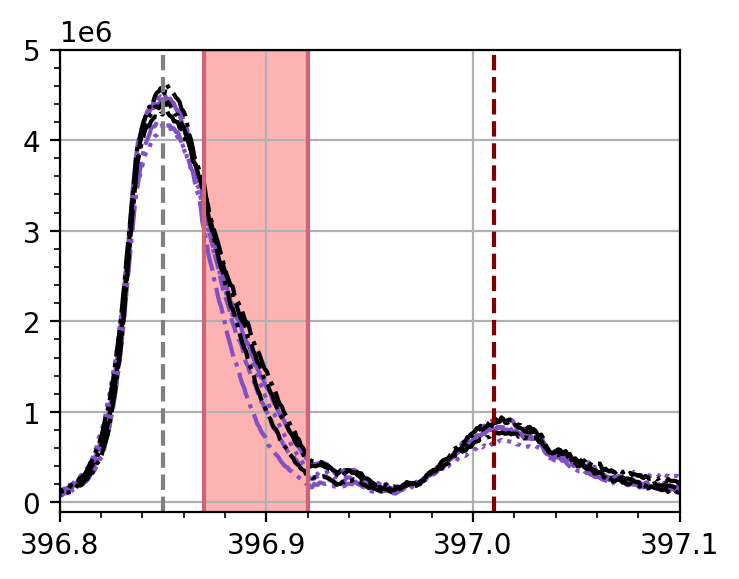

In [61]:
fig,ax=plt.subplots(dpi=200,figsize=(4,3));
l=0
inds=[10,21,35,48] #minima between peaks
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[0]],linestyle='dashdot',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[1]],linestyle='dashed',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[2]],linestyle='solid',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[3]],linestyle='dotted',color='#8250C4')

ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[1]+inds[0])/2))],linestyle='dashdot',color='black')
ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[2]+inds[1])/2))],linestyle='dashdot',color='black')
ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[3]+inds[2])/2))],linestyle='dashdot',color='black')


ax.set_xlim([396.8,397.08])
ax.set_ylim([-0.1e6,5e6])
ax.set_xticks([396.8,396.9,397.0,397.1])
ax.axvline(396.87,c='#CC6677')
ax.axvline(396.92,c='#CC6677')
ax.axvline(396.85,c='grey',linestyle='dashed')
ax.axvline(397.01,c='maroon',linestyle='dashed')
ax.axvspan(396.87, 396.92, color='red', alpha=0.3)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid()

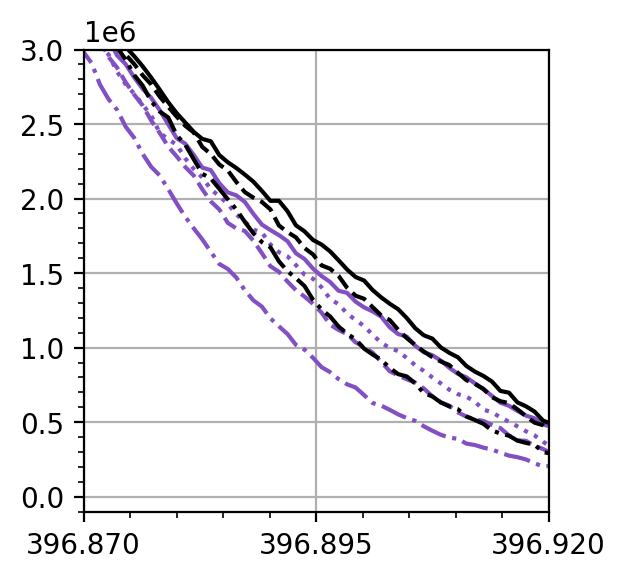

In [65]:
fig,ax=plt.subplots(dpi=200,figsize=(3,3));
l=0
inds=[10,21,35,48] #minima between peaks
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[0]],linestyle='dashdot',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[1]],linestyle='dashed',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[2]],linestyle='solid',color='#8250C4')
ax.plot(wl,intensity[poschoice,:,ylo+20+inds[3]],linestyle='dotted',color='#8250C4')

ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[1]+inds[0])/2))],linestyle='dashdot',color='black')
ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[2]+inds[1])/2))],linestyle='dashed',color='black')
ax.plot(wl,intensity[poschoice,:,int(ylo+20+np.round((inds[3]+inds[2])/2))],linestyle='solid',color='black')


ax.set_xlim([396.87,396.92])
ax.set_ylim([-0.1e6,3e6])
ax.set_xticks([396.87,396.895,396.92])
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid()


In [28]:
def find_nearest(array, value):
    array = np.asarray(array)
    # 1. Calculate absolute differences
    # 2. Find index of minimum difference
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

val, idx = find_nearest(wl[wllo:wlhi],396.9)

In [29]:
alongcut = np.arange(ylo+20,yhi-40)

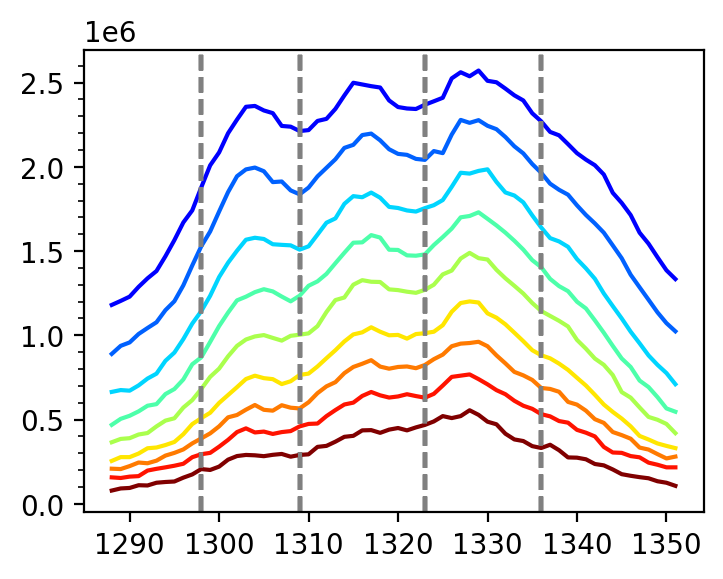

In [30]:
fig,ax=plt.subplots(dpi=200,figsize=(4,3));
l=0
for i in np.linspace(396.881,396.92,9):
    l=l+1
    val, idx = find_nearest(wl,i)
    ax.plot(np.arange(ylo+20,yhi-40),intensity[poschoice,idx,ylo+20:yhi-40],c=colors[l])
    ax.axvline(ylo+20+10,linestyle='dashed',color='grey')
    ax.axvline(ylo+20+21,linestyle='dashed',color='grey')
    ax.axvline(ylo+20+35,linestyle='dashed',color='grey')
    ax.axvline(ylo+20+48,linestyle='dashed',color='grey')

#ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

In [35]:
# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C


fwhm: 141.13238958210928
fwhm: 157.7786891255159
fwhm: 171.32108063190324


(1400000.0, 2400000.0)

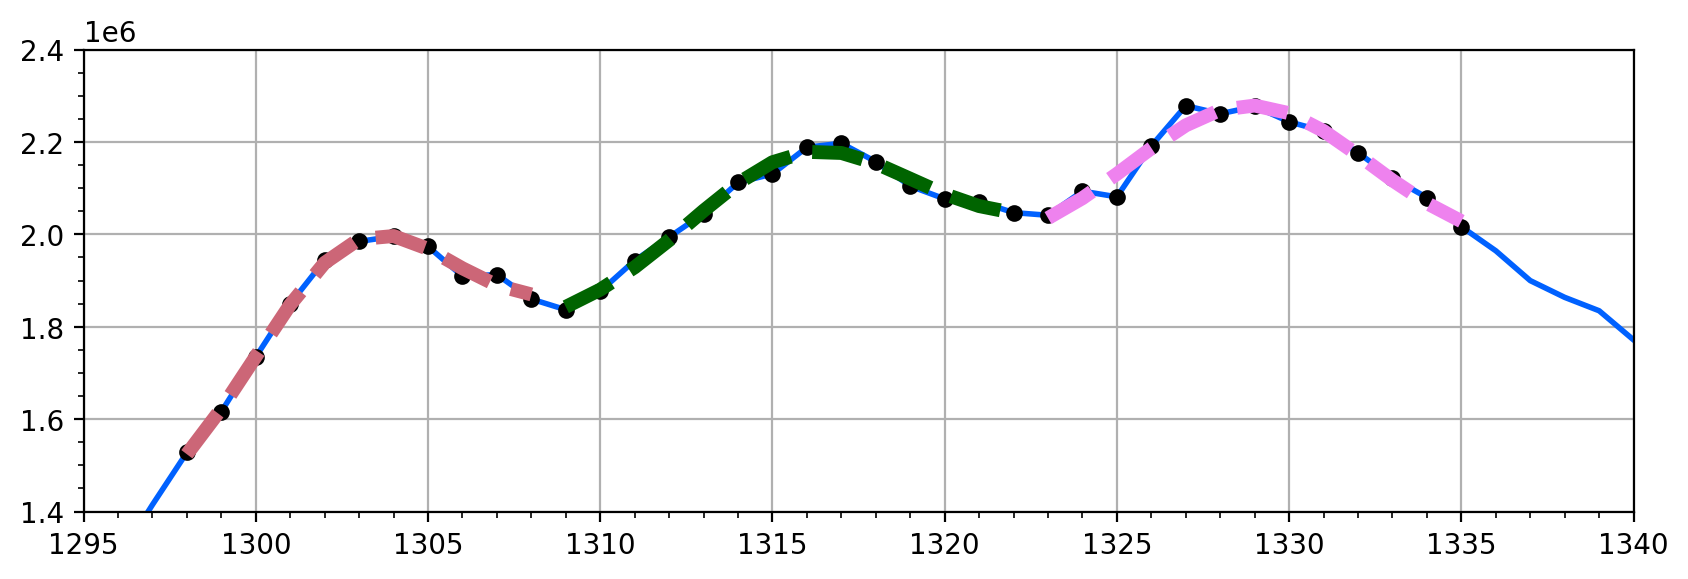

In [81]:
inds=[10,21,35,48]

wavechoice = np.linspace(396.881,396.92,9)
val, idx = find_nearest(wl,wavechoice[1])
curve = intensity[poschoice,idx,ylo+20:yhi-40]

fig,ax=plt.subplots(dpi=200,figsize=(10,3))

ax.plot(alongcut,curve,color=colors[2],linewidth=2)

# x = positions
x = alongcut[inds[0]:inds[1]]
y = curve[inds[0]:inds[1]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm:", sigma*2.3548*0.029*727)

# Plot
ax.plot(x, y,'k.', label='Data',markersize=10)
ax.plot(x, gaussian_linear(x, *params), '--', c='#CC6677',linewidth=5, label='Fit')

# x = positions
x = alongcut[inds[1]:inds[2]]
y = curve[inds[1]:inds[2]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm:", sigma*2.3548*0.029*727)

# Plot
ax.plot(x, y, 'k.', label='Data',markersize=10)
ax.plot(x, gaussian_linear(x, *params), '--',c='darkgreen',linewidth=5,  label='Fit')

# x = positions
x = alongcut[inds[2]:inds[3]]
y = curve[inds[2]:inds[3]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm:", sigma*2.3548*0.029*727)


# Plot
ax.plot(x, y, 'k.', label='Data',markersize=10)
ax.plot(x, gaussian_linear(x, *params), '--',c='violet',linewidth=5,  label='Fit')

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid()
ax.set_xlim([1295,1340])
ax.set_ylim([1.4e6,2.4e6])


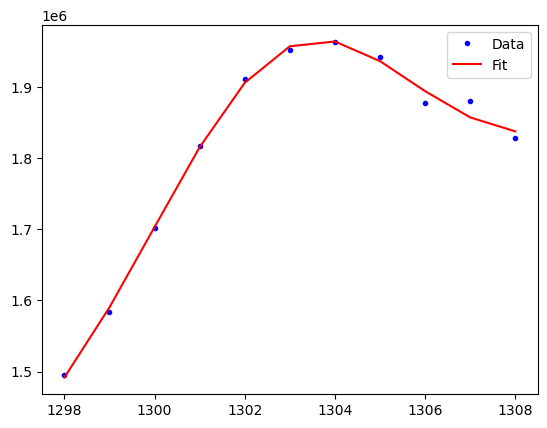

Amplitude: 372960.71518228657
Center: 1302.832980420149
Sigma: 2.8427595099301097
fwhm: 6.694130093983422
width: 141.1323447714525 km
linear slope: 36237.09867886257
Offset: -45632056.868628874


In [115]:
# x = positions
x = alongcut[inds[0]:inds[1]]
y = curve[inds[0]:inds[1]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.029*727,'km')
print("linear slope:", B)
print("Offset:", C)

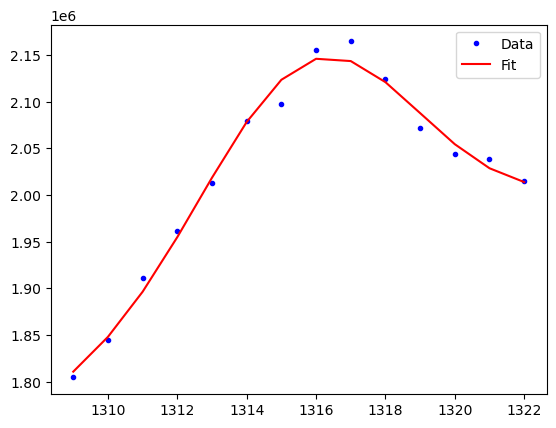

Amplitude: 259561.84600543755
Center: 1315.8106759048203
Sigma: 3.178060186218416
fwhm: 7.483696126507127
width: 157.77876543514975 km
linear slope: 14653.739330920675
Offset: -17397236.17027911


In [116]:

# x = positions
x = alongcut[inds[1]:inds[2]]
y = curve[inds[1]:inds[2]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.029*727,'km')
print("linear slope:", B)
print("Offset:", C)

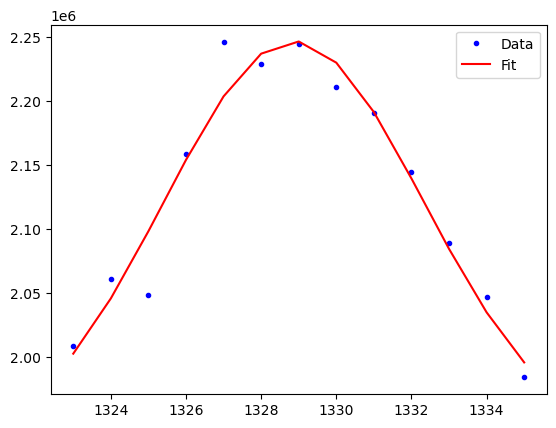

Amplitude: 317460.0422731852
Center: 1328.85047491502
Sigma: 3.450838298921343
fwhm: 8.126034026299978
width: 171.32117537648244 km
linear slope: 309.7785376584805
Offset: 1517522.9676055075


In [117]:

# x = positions
x = alongcut[inds[2]:inds[3]]
y = curve[inds[2]:inds[3]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 3, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.029*727,'km')
print("linear slope:", B)
print("Offset:", C)

In [ ]:
#lengthened relative to VBI because of direction of cut maybe?